# Video Game Sales and Market-Profile Clustering

This academic project studies relationships between video-game sales, genre, platform, release period and geographic market.

It revisits a study completed in 2020 - my first practical exposure to machine learning and the project that motivated me to pursue Data Science.

## Research framing

The main idea is:

> Video-game sales are connected to genre, platform, release period and geographic market.

The dataset describes games and market outcomes, not individual consumers. The analysis therefore identifies **video-game and market profiles**, not demographic groups or types of gamers.

## Models

1. **K-Means:** release year, European sales and one-hot encoded genre.
2. **X-Means:** one-hot encoded genre and platform.
3. **Affinity Propagation:** regional market shares, sales volume and release-period profiles.

An Agglomerative Clustering model is included as a compact reference model for Case 3.

## 1. Imports and Configuration

The code is intentionally organised as an intermediate-level academic workflow. Each transformation is visible and the clustering metrics are calculated explicitly.

In [4]:
import os
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import AffinityPropagation, AgglomerativeClustering, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# pyclustering currently expects NumPy to expose the standard warnings module.
np.warnings = warnings
from pyclustering.cluster.xmeans import splitting_type, xmeans

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
DATA_PATH = Path(r"E:\data\Video_Games_Sales.csv")
SILHOUETTE_SAMPLE = 4_000

In [5]:
def clustering_metrics(features, labels, sample_size=None):
    # Return three internal clustering metrics in a compact dictionary.
    labels = np.asarray(labels)
    n_clusters = len(np.unique(labels))

    if n_clusters < 2:
        return {
            "Clusters": n_clusters,
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
        }

    if sample_size and len(features) > sample_size:
        silhouette = silhouette_score(
            features,
            labels,
            sample_size=sample_size,
            random_state=RANDOM_STATE,
        )
    else:
        silhouette = silhouette_score(features, labels)

    return {
        "Clusters": n_clusters,
        "Silhouette": silhouette,
        "Davies_Bouldin": davies_bouldin_score(features, labels),
        "Calinski_Harabasz": calinski_harabasz_score(features, labels),
    }


def top_categories(frame, cluster_column, category_column, n=3):
    # Return the most common values of a category inside every cluster.
    return frame.groupby(cluster_column)[category_column].apply(
        lambda values: ", ".join(values.value_counts().head(n).index.astype(str))
    )


def weighted_top_categories(
    frame,
    cluster_column,
    category_column,
    weight_column="Title_Count",
    n=3,
):
    # Return categories contributing the largest number of titles.
    output = {}
    for cluster, group in frame.groupby(cluster_column):
        ranked = (
            group.groupby(category_column)[weight_column]
            .sum()
            .sort_values(ascending=False)
            .head(n)
        )
        output[cluster] = ", ".join(ranked.index.astype(str))
    return pd.Series(output)

## 2. Load the Complete Dataset

The complete local dataset is used. No row limit or random sampling is applied.

In [6]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH}. Update DATA_PATH before running the notebook."
    )

games = pd.read_csv(DATA_PATH)
games = games.rename(columns={"Year_of_Release": "Year"})

print(f"Rows: {len(games):,}")
print(f"Columns: {games.shape[1]}")
display(games.head())

Rows: 16,719
Columns: 16


,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8.0,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8.0,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
quality_summary = pd.DataFrame(
    {
        "Data_Type": games.dtypes.astype(str),
        "Missing": games.isna().sum(),
        "Missing_%": games.isna().mean().mul(100),
        "Unique": games.nunique(dropna=True),
    }
).sort_values("Missing_%", ascending=False)

print(f"Exact duplicate rows: {games.duplicated().sum():,}")
display(quality_summary.round(2))

Exact duplicate rows: 0


,Data_Type,Missing,Missing_%,Unique
User_Score,float64,9129,54.60,95
User_Count,float64,9129,54.60,888
Critic_Score,float64,8582,51.33,82
Critic_Count,float64,8582,51.33,106
Rating,object,6769,40.49,8
Developer,object,6623,39.61,1696
Year,float64,269,1.61,39
Publisher,object,54,0.32,582
Name,object,2,0.01,11562
Genre,object,2,0.01,12


## 3. Feature Engineering

All source rows are retained.

- Missing categorical values are labelled `Unknown`.
- Missing years are handled inside the relevant preprocessing pipeline.
- Regional sales shares describe the geographic distribution of each game's sales.
- European sales are log-transformed before K-Means to reduce extreme positive skewness.
- Release eras support the market-profile analysis.

In [8]:
games = games.copy()

for column in ["Name", "Genre", "Platform", "Publisher"]:
    games[column] = games[column].fillna("Unknown")

sales_columns = ["NA_Sales", "EU_Sales", "JP_Sales", "Other_Sales"]
games["Regional_Sales_Total"] = games[sales_columns].sum(axis=1)

for region in ["NA", "EU", "JP", "Other"]:
    games[f"{region}_Share"] = np.where(
        games["Regional_Sales_Total"] > 0,
        games[f"{region}_Sales"] / games["Regional_Sales_Total"],
        0.0,
    )

games["Log_EU_Sales"] = np.log1p(games["EU_Sales"])

games["Release_Era"] = pd.cut(
    games["Year"],
    bins=[-np.inf, 1989, 1999, 2009, np.inf],
    labels=["Before 1990", "1990s", "2000s", "2010s+"],
).astype("object")
games["Release_Era"] = games["Release_Era"].fillna("Unknown")

sales_check = (games["Regional_Sales_Total"] - games["Global_Sales"]).abs()

print(f"Rows retained: {len(games):,}")
print(f"Genres: {games['Genre'].nunique()}")
print(f"Platforms: {games['Platform'].nunique()}")
print(f"Median absolute regional/global rounding difference: {sales_check.median():.4f}")

Rows retained: 16,719
Genres: 13
Platforms: 31
Median absolute regional/global rounding difference: 0.0000


## 4. Exploratory Market View

The first visual compares the geographic sales composition of each genre. The second shows the leading platforms by total global sales.

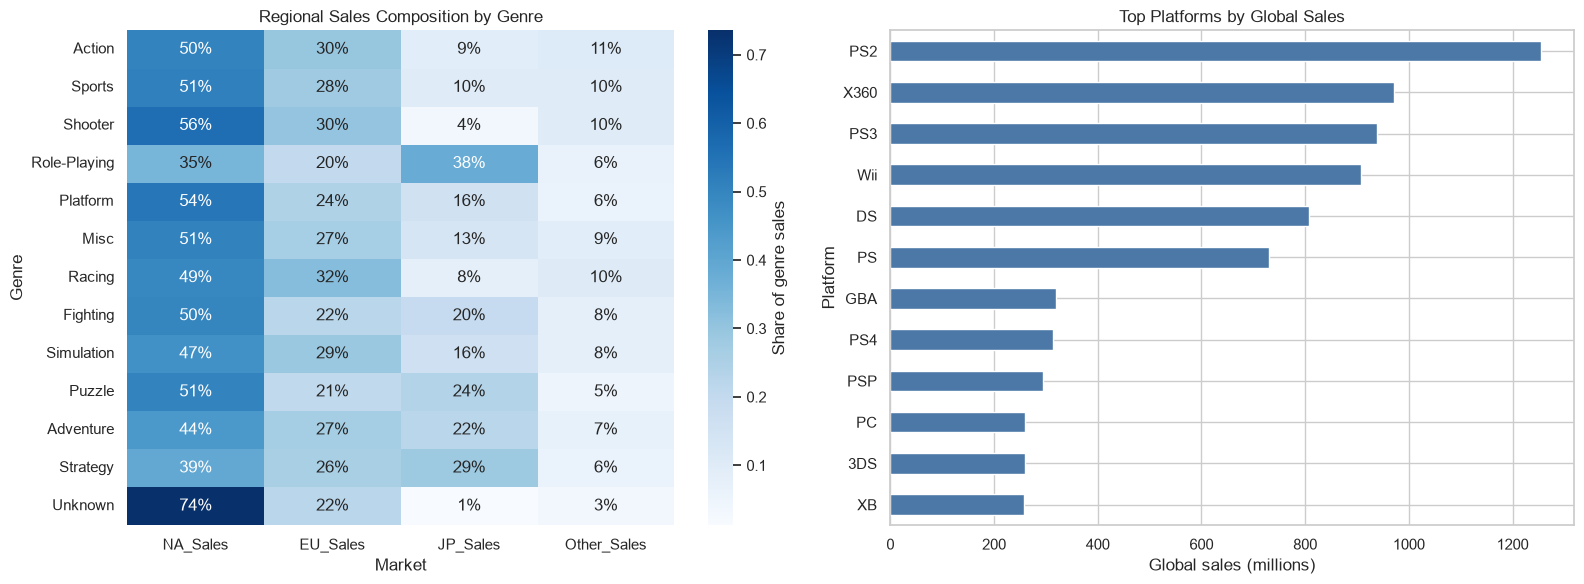

In [9]:
genre_sales = games.groupby("Genre")[sales_columns].sum()
genre_shares = genre_sales.div(genre_sales.sum(axis=1), axis=0)
genre_order = games.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    genre_shares.loc[genre_order],
    cmap="Blues",
    annot=True,
    fmt=".0%",
    cbar_kws={"label": "Share of genre sales"},
    ax=axes[0],
)
axes[0].set_title("Regional Sales Composition by Genre")
axes[0].set_xlabel("Market")
axes[0].set_ylabel("Genre")

platform_sales = (
    games.groupby("Platform")["Global_Sales"]
    .sum()
    .nlargest(12)
    .sort_values()
)
platform_sales.plot(kind="barh", color="#4C78A8", ax=axes[1])
axes[1].set_title("Top Platforms by Global Sales")
axes[1].set_xlabel("Global sales (millions)")
axes[1].set_ylabel("Platform")

plt.tight_layout()
plt.show()

# Case 1 - K-Means

The first model uses:

- `Year`
- log-transformed `EU_Sales`
- one-hot encoded `Genre`

Numeric features are median-imputed and standardised. Genre is converted to dummy variables. Values from `k=2` to `k=10` are evaluated, but the final `k=5` solution is retained for richer interpretation and continuity with the original academic study.

In [10]:
kmeans_numeric = ["Year", "Log_EU_Sales"]
kmeans_category = ["Genre"]

kmeans_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            kmeans_numeric,
        ),
        (
            "genre",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            kmeans_category,
        ),
    ]
)

X_kmeans = kmeans_preprocessor.fit_transform(
    games[kmeans_numeric + kmeans_category]
)

print(f"K-Means matrix shape: {X_kmeans.shape}")

K-Means matrix shape: (16719, 15)


In [11]:
kmeans_diagnostics = []

for k in range(2, 11):
    candidate = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate.fit_predict(X_kmeans)
    metrics = clustering_metrics(
        X_kmeans,
        candidate_labels,
        sample_size=SILHOUETTE_SAMPLE,
    )
    metrics["k"] = k
    metrics["Inertia"] = candidate.inertia_
    kmeans_diagnostics.append(metrics)

kmeans_diagnostics = pd.DataFrame(kmeans_diagnostics)
display(kmeans_diagnostics.set_index("k").round(4))

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inertia
k,,,,,
2,2,0.4841,1.0139,4834.9384,37500.6506
3,3,0.2758,1.2199,6264.0711,27635.0417
4,4,0.1723,1.5613,5247.9146,24896.6733
5,5,0.1800,1.4635,4820.9703,22447.6114
6,6,0.1852,1.4957,4394.0972,20887.9379
7,7,0.2083,1.4451,4055.0017,19686.4083
8,8,0.2320,1.4269,3835.2870,18548.1700
9,9,0.2314,1.5568,3638.2126,17633.1139
10,10,0.2577,1.4490,3490.9635,16785.0353


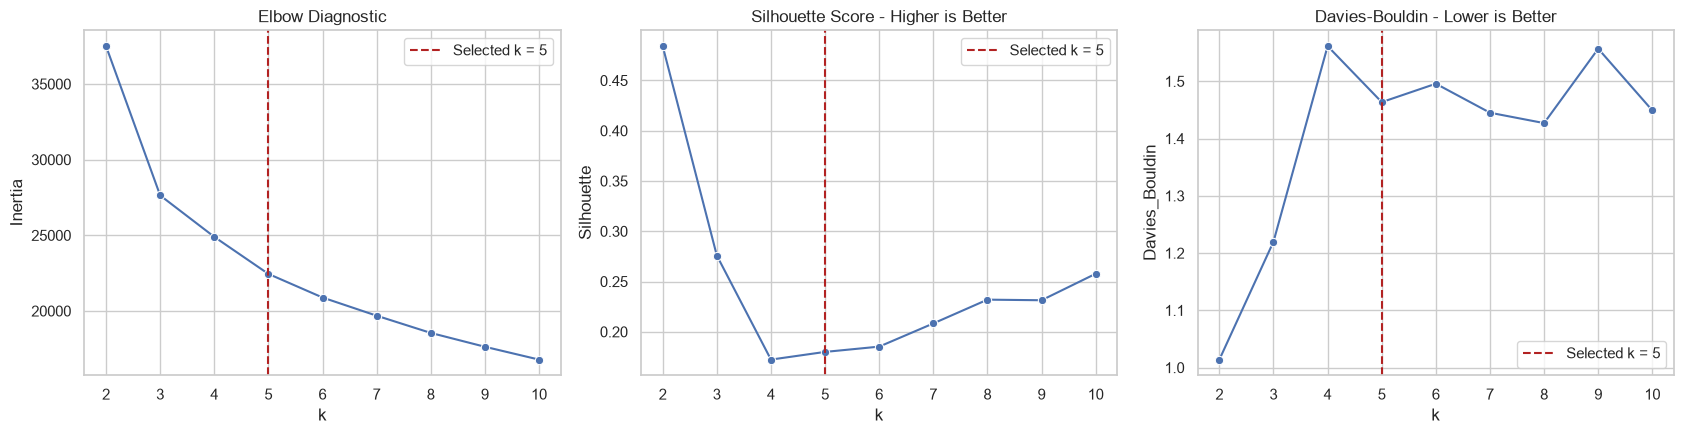

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

sns.lineplot(data=kmeans_diagnostics, x="k", y="Inertia", marker="o", ax=axes[0])
sns.lineplot(data=kmeans_diagnostics, x="k", y="Silhouette", marker="o", ax=axes[1])
sns.lineplot(data=kmeans_diagnostics, x="k", y="Davies_Bouldin", marker="o", ax=axes[2])

axes[0].set_title("Elbow Diagnostic")
axes[1].set_title("Silhouette Score - Higher is Better")
axes[2].set_title("Davies-Bouldin - Lower is Better")

for axis in axes:
    axis.axvline(5, color="firebrick", linestyle="--", label="Selected k = 5")
    axis.legend()

plt.tight_layout()
plt.show()

In [13]:
KMEANS_K = 5

kmeans_model = KMeans(
    n_clusters=KMEANS_K,
    n_init=20,
    random_state=RANDOM_STATE,
)
games["KMeans_Cluster"] = kmeans_model.fit_predict(X_kmeans)

kmeans_metrics = clustering_metrics(
    X_kmeans,
    games["KMeans_Cluster"],
    sample_size=SILHOUETTE_SAMPLE,
)

display(pd.DataFrame([kmeans_metrics], index=["K-Means"]).round(4))

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
K-Means,5,0.18,1.4635,4820.9703


In [14]:
kmeans_profile = (
    games.groupby("KMeans_Cluster")
    .agg(
        Games=("Name", "size"),
        Median_Year=("Year", "median"),
        Median_EU_Sales=("EU_Sales", "median"),
        Mean_EU_Sales=("EU_Sales", "mean"),
        Total_Global_Sales=("Global_Sales", "sum"),
    )
)
kmeans_profile["Share_%"] = kmeans_profile["Games"].div(len(games)).mul(100)
kmeans_profile["Top_Genres"] = top_categories(
    games,
    "KMeans_Cluster",
    "Genre",
    n=3,
)

display(kmeans_profile.round(2))

,Games,Median_Year,Median_EU_Sales,Mean_EU_Sales,Total_Global_Sales,Share_%,Top_Genres
KMeans_Cluster,,,,,,,
0,6110,2011.0,0.01,0.05,1299.94,36.55,"Action, Misc, Adventure"
1,1444,2008.0,0.52,0.60,2436.88,8.64,"Action, Shooter, Sports"
2,6671,2005.0,0.02,0.04,1721.06,39.90,"Sports, Action, Misc"
3,293,2008.0,2.05,2.75,2285.31,1.75,"Action, Shooter, Sports"
4,2201,1997.0,0.03,0.08,1177.11,13.16,"Sports, Action, Fighting"


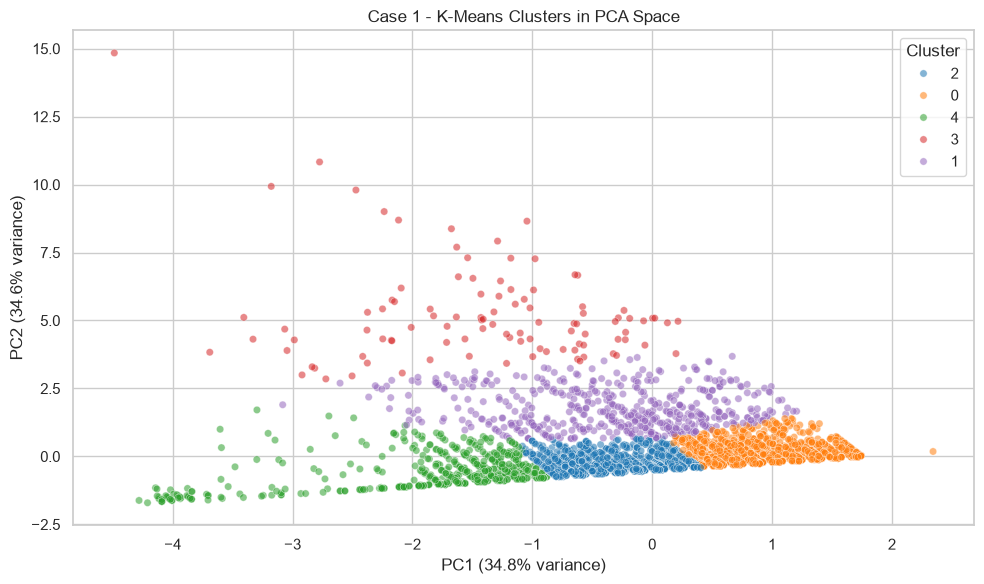

In [15]:
kmeans_pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
kmeans_pca = kmeans_pca_model.fit_transform(X_kmeans)

kmeans_plot = pd.DataFrame(
    {
        "PC1": kmeans_pca[:, 0],
        "PC2": kmeans_pca[:, 1],
        "Cluster": games["KMeans_Cluster"].astype(str),
    }
)
kmeans_plot = kmeans_plot.sample(
    n=min(6_000, len(kmeans_plot)),
    random_state=RANDOM_STATE,
)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=kmeans_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.55,
    s=28,
)
plt.title("Case 1 - K-Means Clusters in PCA Space")
plt.xlabel(f"PC1 ({kmeans_pca_model.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({kmeans_pca_model.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

### Case 1 interpretation

The diagnostic metrics may favour a compact solution because a small number of broad sales patterns are strongly separated. The five-cluster model is kept deliberately: it offers a more detailed descriptive view and allows the modern analysis to remain connected to the original study.

The clusters describe combinations of release period, European sales intensity and genre. They do not represent individual gamers.

# Case 2 - X-Means

X-Means extends K-Means by testing whether existing clusters should be split. This case uses only:

- one-hot encoded `Genre`
- one-hot encoded `Platform`

All inputs are numerical after encoding; no mixed-distance measure is used. The model starts with two clusters and may expand up to ten using the Bayesian Information Criterion.

In [16]:
xmeans_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False,
)
X_xmeans = xmeans_encoder.fit_transform(games[["Genre", "Platform"]])

XMEANS_K_MIN = 2
XMEANS_K_MAX = 10

# Stable initial centres are produced with scikit-learn K-Means.
initial_model = KMeans(
    n_clusters=XMEANS_K_MIN,
    n_init=20,
    random_state=RANDOM_STATE,
).fit(X_xmeans)

xmeans_model = xmeans(
    X_xmeans.tolist(),
    initial_model.cluster_centers_.tolist(),
    kmax=XMEANS_K_MAX,
    criterion=splitting_type.BAYESIAN_INFORMATION_CRITERION,
    ccore=True,
    random_state=RANDOM_STATE,
)
xmeans_model.process()
xmeans_clusters = xmeans_model.get_clusters()

xmeans_labels = np.full(len(games), -1, dtype=int)
for cluster_id, row_indices in enumerate(xmeans_clusters):
    xmeans_labels[row_indices] = cluster_id

games["XMeans_Cluster"] = xmeans_labels

print(f"Clusters selected by X-Means: {len(xmeans_clusters)}")
print("Cluster sizes:", [len(cluster) for cluster in xmeans_clusters])

if len(xmeans_clusters) == XMEANS_K_MAX:
    print(
        "Note: X-Means reached the upper boundary. "
        "The one-hot feature space supports a granular catalogue segmentation."
    )

Clusters selected by X-Means: 10
Cluster sizes: [9114, 672, 93, 860, 71, 2042, 237, 260, 2990, 380]
Note: X-Means reached the upper boundary. The one-hot feature space supports a granular catalogue segmentation.


In [17]:
xmeans_metrics = clustering_metrics(
    X_xmeans,
    games["XMeans_Cluster"],
    sample_size=SILHOUETTE_SAMPLE,
)

xmeans_profile = (
    games.groupby("XMeans_Cluster")
    .agg(
        Games=("Name", "size"),
        Total_Global_Sales=("Global_Sales", "sum"),
        Median_Year=("Year", "median"),
    )
)
xmeans_profile["Share_%"] = xmeans_profile["Games"].div(len(games)).mul(100)
xmeans_profile["Top_Genres"] = top_categories(
    games,
    "XMeans_Cluster",
    "Genre",
    n=3,
)
xmeans_profile["Top_Platforms"] = top_categories(
    games,
    "XMeans_Cluster",
    "Platform",
    n=3,
)

display(pd.DataFrame([xmeans_metrics], index=["X-Means"]).round(4))
display(xmeans_profile.sort_values("Games", ascending=False).round(2))

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
X-Means,10,0.0741,1.7365,655.7175


,Games,Total_Global_Sales,Median_Year,Share_%,Top_Genres,Top_Platforms
XMeans_Cluster,,,,,,
0,9114,4344.42,2007.0,54.51,"Misc, Role-Playing, Shooter","DS, PS2, PSP"
8,2990,1443.72,2008.0,17.88,Action,"PS2, DS, X360"
5,2042,987.79,2005.0,12.21,Sports,"PS2, PS, X360"
3,860,732.30,2004.0,5.14,Platform,"GBA, PS2, DS"
1,672,355.84,2009.0,4.02,"Misc, Simulation, Adventure",Wii
9,380,301.55,2011.0,2.27,Action,PS3
7,260,288.61,2009.0,1.56,Sports,Wii
6,237,210.35,2015.0,1.42,"Role-Playing, Sports, Shooter",PS4
2,93,60.25,2009.0,0.56,Racing,Wii


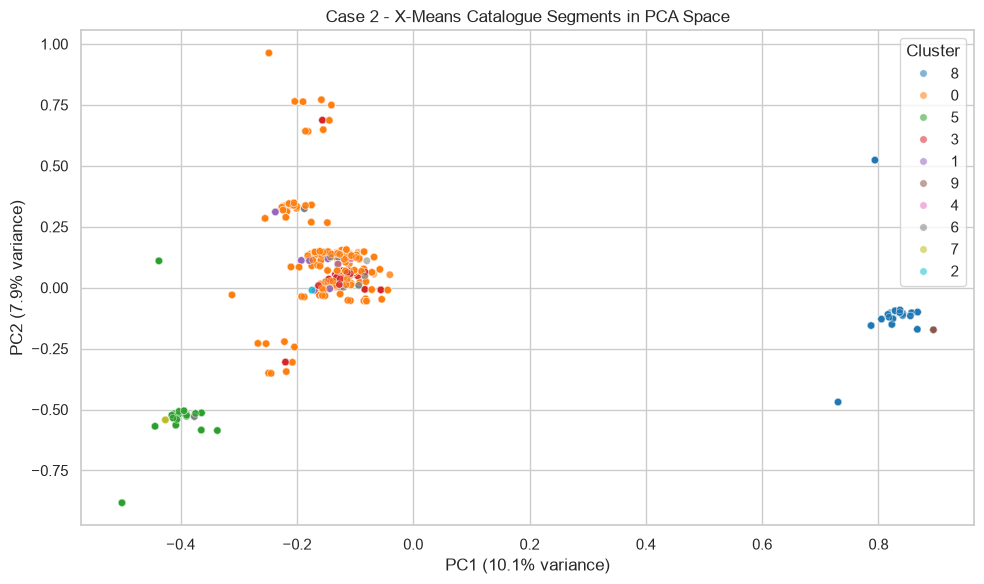

In [18]:
xmeans_pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
xmeans_pca = xmeans_pca_model.fit_transform(X_xmeans)

xmeans_plot = pd.DataFrame(
    {
        "PC1": xmeans_pca[:, 0],
        "PC2": xmeans_pca[:, 1],
        "Cluster": games["XMeans_Cluster"].astype(str),
    }
).sample(n=min(6_000, len(games)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=xmeans_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.55,
    s=28,
)
plt.title("Case 2 - X-Means Catalogue Segments in PCA Space")
plt.xlabel(f"PC1 ({xmeans_pca_model.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({xmeans_pca_model.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

### Case 2 interpretation

This model identifies recurring **genre-platform combinations** in the video-game catalogue. Large clusters capture common combinations, while smaller clusters capture specialised platform or genre niches.

Because sales variables are not included, the model describes catalogue structure rather than geographic market performance.

# Case 3 - Affinity Propagation on Market Profiles

Affinity Propagation uses pairwise similarities and therefore has approximately quadratic memory requirements. Running it directly on 16,719 games would be unnecessarily expensive.

Instead, every source row contributes to a profile defined by:

```text
Genre x Platform x Release Era
```

The clustering attributes are:

- North American, European, Japanese and other-region sales shares,
- log number of titles,
- log total global sales,
- mean release year.

Genre, platform and era identify each profile and are used for interpretation. The numeric features determine market similarity.

In [19]:
market_profiles = (
    games.groupby(["Genre", "Platform", "Release_Era"], observed=True)
    .agg(
        Title_Count=("Name", "size"),
        Total_Global_Sales=("Global_Sales", "sum"),
        Mean_Year=("Year", "mean"),
        NA_Sales=("NA_Sales", "sum"),
        EU_Sales=("EU_Sales", "sum"),
        JP_Sales=("JP_Sales", "sum"),
        Other_Sales=("Other_Sales", "sum"),
    )
    .reset_index()
)

market_profiles["Regional_Sales_Total"] = market_profiles[sales_columns].sum(axis=1)

for region in ["NA", "EU", "JP", "Other"]:
    market_profiles[f"{region}_Share"] = np.where(
        market_profiles["Regional_Sales_Total"] > 0,
        market_profiles[f"{region}_Sales"] / market_profiles["Regional_Sales_Total"],
        0.0,
    )

market_profiles["Log_Title_Count"] = np.log1p(market_profiles["Title_Count"])
market_profiles["Log_Total_Global_Sales"] = np.log1p(
    market_profiles["Total_Global_Sales"]
)

print(f"Source games represented: {market_profiles['Title_Count'].sum():,}")
print(f"Market profiles: {len(market_profiles):,}")
display(market_profiles.head())

Source games represented: 16,719
Market profiles: 535


,Genre,Platform,Release_Era,Title_Count,Total_Global_Sales,Mean_Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Regional_Sales_Total,NA_Share,EU_Share,JP_Share,Other_Share,Log_Title_Count,Log_Total_Global_Sales
0,Action,2600,Before 1990,55,26.39,1982.054545,24.63,1.47,0.00,0.21,26.31,0.936146,0.055872,0.00000,0.007982,4.025352,3.310178
1,Action,2600,Unknown,6,2.95,NaN,2.76,0.17,0.00,0.01,2.94,0.938776,0.057823,0.00000,0.003401,1.945910,1.373716
2,Action,3DS,2010s+,187,57.93,2013.363636,19.62,12.66,22.66,2.90,57.84,0.339212,0.218880,0.39177,0.050138,5.236442,4.076350
3,Action,3DS,Unknown,1,0.40,NaN,0.18,0.19,0.00,0.03,0.40,0.450000,0.475000,0.00000,0.075000,0.693147,0.336472
4,Action,DC,1990s,1,0.08,1998.000000,0.00,0.00,0.08,0.00,0.08,0.000000,0.000000,1.00000,0.000000,0.693147,0.076961


In [20]:
affinity_features = [
    "NA_Share",
    "EU_Share",
    "JP_Share",
    "Other_Share",
    "Log_Title_Count",
    "Log_Total_Global_Sales",
    "Mean_Year",
]

affinity_preprocessor = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

X_affinity = affinity_preprocessor.fit_transform(
    market_profiles[affinity_features]
)

print(f"Affinity Propagation matrix shape: {X_affinity.shape}")

Affinity Propagation matrix shape: (535, 7)


### Preference diagnostic

Affinity Propagation does not require a predefined number of clusters. Its `preference` parameter controls how readily observations become cluster exemplars.

A short, transparent diagnostic evaluates a small set of preference values. The final value is selected using the highest Silhouette score among these candidates.

In [21]:
preference_candidates = [-30, -40, -50, -60, -80, -100]
affinity_diagnostics = []

for preference in preference_candidates:
    candidate = AffinityPropagation(
        damping=0.85,
        preference=preference,
        max_iter=500,
        convergence_iter=30,
        random_state=RANDOM_STATE,
    )
    candidate_labels = candidate.fit_predict(X_affinity)
    metrics = clustering_metrics(X_affinity, candidate_labels)
    metrics["Preference"] = preference
    metrics["Iterations"] = candidate.n_iter_
    affinity_diagnostics.append(metrics)

affinity_diagnostics = pd.DataFrame(affinity_diagnostics)
display(affinity_diagnostics.set_index("Preference").round(4))

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Iterations
Preference,,,,,
-30,16,0.2423,1.2349,148.8334,56
-40,13,0.2678,1.2052,158.5045,53
-50,11,0.2739,1.1869,172.7628,53
-60,10,0.2691,1.2605,175.8414,64
-80,7,0.2531,1.3237,192.5803,75
-100,6,0.2746,1.2390,207.4969,52


In [22]:
AFFINITY_PREFERENCE = float(
    affinity_diagnostics.loc[
        affinity_diagnostics["Silhouette"].idxmax(),
        "Preference",
    ]
)

affinity_model = AffinityPropagation(
    damping=0.85,
    preference=AFFINITY_PREFERENCE,
    max_iter=500,
    convergence_iter=30,
    random_state=RANDOM_STATE,
)
market_profiles["Affinity_Cluster"] = affinity_model.fit_predict(X_affinity)

affinity_metrics = clustering_metrics(
    X_affinity,
    market_profiles["Affinity_Cluster"],
)

print(f"Selected preference: {AFFINITY_PREFERENCE:g}")
print(f"Affinity Propagation clusters: {affinity_metrics['Clusters']}")
display(pd.DataFrame([affinity_metrics], index=["Affinity Propagation"]).round(4))

Selected preference: -100
Affinity Propagation clusters: 6


,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
Affinity Propagation,6,0.2746,1.239,207.4969


In [23]:
affinity_profile = (
    market_profiles.groupby("Affinity_Cluster")
    .agg(
        Profiles=("Genre", "size"),
        Titles=("Title_Count", "sum"),
        Total_Global_Sales=("Total_Global_Sales", "sum"),
        Mean_Year=("Mean_Year", "mean"),
        NA_Sales=("NA_Sales", "sum"),
        EU_Sales=("EU_Sales", "sum"),
        JP_Sales=("JP_Sales", "sum"),
        Other_Sales=("Other_Sales", "sum"),
    )
)

affinity_profile["Regional_Total"] = affinity_profile[sales_columns].sum(axis=1)
for region in ["NA", "EU", "JP", "Other"]:
    affinity_profile[f"{region}_Share"] = (
        affinity_profile[f"{region}_Sales"]
        / affinity_profile["Regional_Total"]
    )

affinity_profile["Top_Genres"] = weighted_top_categories(
    market_profiles,
    "Affinity_Cluster",
    "Genre",
)
affinity_profile["Top_Platforms"] = weighted_top_categories(
    market_profiles,
    "Affinity_Cluster",
    "Platform",
)
affinity_profile["Top_Eras"] = weighted_top_categories(
    market_profiles,
    "Affinity_Cluster",
    "Release_Era",
)

profile_columns = [
    "Profiles",
    "Titles",
    "Total_Global_Sales",
    "Mean_Year",
    "NA_Share",
    "EU_Share",
    "JP_Share",
    "Other_Share",
    "Top_Genres",
    "Top_Platforms",
    "Top_Eras",
]
display(affinity_profile[profile_columns].round(3))

,Profiles,Titles,Total_Global_Sales,Mean_Year,NA_Share,EU_Share,JP_Share,Other_Share,Top_Genres,Top_Platforms,Top_Eras
Affinity_Cluster,,,,,,,,,,,
0,100,522,171.53,1998.470,0.682,0.175,0.113,0.031,"Simulation, Shooter, Adventure","XB, GBA, GC","2000s, Unknown, 1990s"
1,63,857,1013.36,1994.261,0.557,0.161,0.258,0.025,"Platform, Action, Fighting","N64, PS, SNES","1990s, 2000s, Before 1990"
2,25,347,52.36,2006.767,0.127,0.772,0.003,0.098,"Adventure, Simulation, Racing","PC, PS4, PS3","2010s+, 2000s, Unknown"
3,88,714,172.33,1997.590,0.057,0.016,0.911,0.015,"Adventure, Role-Playing, Strategy","PSP, SAT, SNES","1990s, 2010s+, 2000s"
4,152,13174,7122.26,2007.550,0.495,0.290,0.116,0.099,"Action, Sports, Misc","PS2, DS, PS3","2000s, 2010s+, 1990s"
5,107,1105,388.46,2011.372,0.457,0.329,0.087,0.127,"Platform, Adventure, Simulation","PSP, PS3, PS4","2010s+, 2000s, Unknown"


In [24]:
exemplars = market_profiles.loc[
    affinity_model.cluster_centers_indices_,
    [
        "Genre",
        "Platform",
        "Release_Era",
        "Title_Count",
        "Total_Global_Sales",
        "NA_Share",
        "EU_Share",
        "JP_Share",
        "Other_Share",
    ],
].copy()
exemplars.insert(0, "Affinity_Cluster", range(len(exemplars)))

print("Representative market profile selected for each cluster:")
display(exemplars.round(3))

Representative market profile selected for each cluster:


,Affinity_Cluster,Genre,Platform,Release_Era,Title_Count,Total_Global_Sales,NA_Share,EU_Share,JP_Share,Other_Share
107,0,Fighting,N64,2000s,5,2.51,0.675,0.155,0.143,0.028
142,1,Misc,GB,1990s,6,11.24,0.540,0.191,0.240,0.028
202,2,Platform,PC,2000s,5,0.16,0.143,0.786,0.000,0.071
270,3,Racing,DC,1990s,3,0.64,0.000,0.000,1.000,0.000
272,4,Racing,DS,2000s,55,34.64,0.536,0.253,0.131,0.080
514,5,Strategy,PS3,2000s,8,2.13,0.507,0.293,0.065,0.135


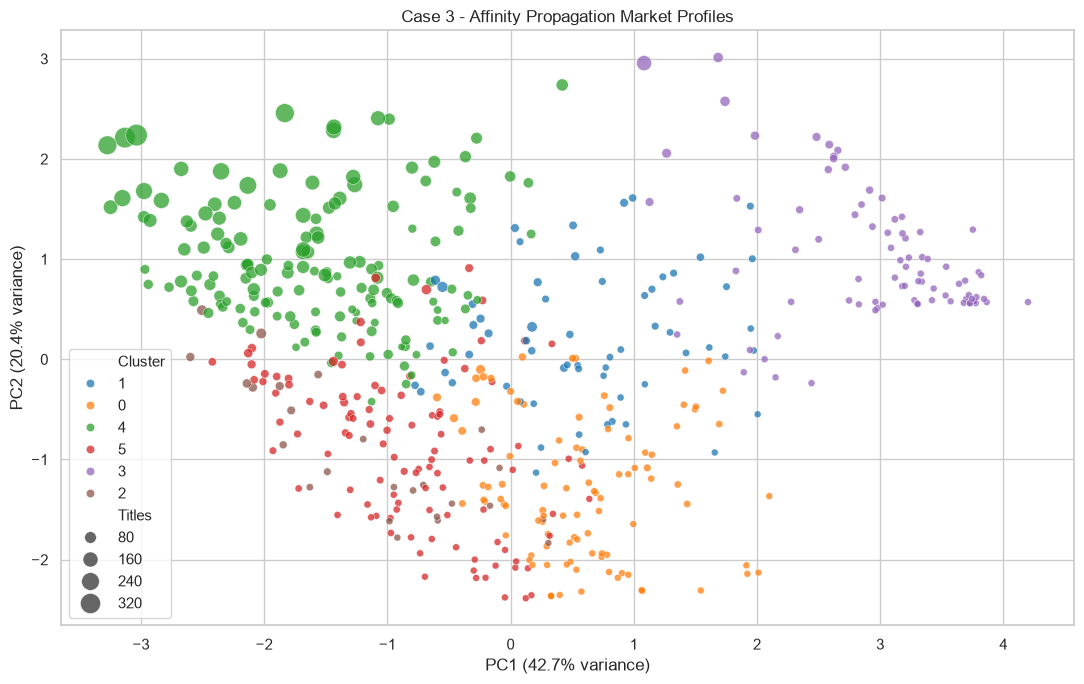

In [25]:
affinity_pca_model = PCA(n_components=2, random_state=RANDOM_STATE)
affinity_pca = affinity_pca_model.fit_transform(X_affinity)

affinity_plot = pd.DataFrame(
    {
        "PC1": affinity_pca[:, 0],
        "PC2": affinity_pca[:, 1],
        "Cluster": market_profiles["Affinity_Cluster"].astype(str),
        "Titles": market_profiles["Title_Count"],
    }
)

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=affinity_plot,
    x="PC1",
    y="PC2",
    hue="Cluster",
    size="Titles",
    sizes=(25, 240),
    palette="tab10",
    alpha=0.75,
)
plt.title("Case 3 - Affinity Propagation Market Profiles")
plt.xlabel(f"PC1 ({affinity_pca_model.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({affinity_pca_model.explained_variance_ratio_[1]:.1%} variance)")
plt.tight_layout()
plt.show()

## Agglomerative Reference Model

Agglomerative Clustering is fitted to the same market-profile features with the same number of clusters discovered by Affinity Propagation. This is a validation reference, not a fourth independent project case.

In [26]:
agglomerative_model = AgglomerativeClustering(
    n_clusters=affinity_metrics["Clusters"],
    linkage="ward",
)
market_profiles["Agglomerative_Cluster"] = agglomerative_model.fit_predict(X_affinity)

agglomerative_metrics = clustering_metrics(
    X_affinity,
    market_profiles["Agglomerative_Cluster"],
)

agreement = adjusted_rand_score(
    market_profiles["Affinity_Cluster"],
    market_profiles["Agglomerative_Cluster"],
)

display(
    pd.DataFrame(
        [affinity_metrics, agglomerative_metrics],
        index=["Affinity Propagation", "Agglomerative"],
    ).round(4)
)
print(f"Adjusted Rand agreement between the two profile solutions: {agreement:.4f}")

,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
Affinity Propagation,6,0.2746,1.2390,207.4969
Agglomerative,6,0.2467,1.2169,184.3066


Adjusted Rand agreement between the two profile solutions: 0.5478


## 5. Diagnostic Summary

The following table summarises internal diagnostics. Scores across different feature spaces or analysis units should **not** be treated as a direct leaderboard.

In [27]:
diagnostic_summary = pd.DataFrame(
    [
        {
            "Model": "K-Means",
            "Analysis_Unit": "Individual game",
            "Observations": len(games),
            **kmeans_metrics,
        },
        {
            "Model": "X-Means",
            "Analysis_Unit": "Individual game",
            "Observations": len(games),
            **xmeans_metrics,
        },
        {
            "Model": "Affinity Propagation",
            "Analysis_Unit": "Market profile",
            "Observations": len(market_profiles),
            **affinity_metrics,
        },
        {
            "Model": "Agglomerative",
            "Analysis_Unit": "Market profile",
            "Observations": len(market_profiles),
            **agglomerative_metrics,
        },
    ]
)

display(diagnostic_summary.set_index("Model").round(4))

,Analysis_Unit,Observations,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
Model,,,,,,
K-Means,Individual game,16719,5,0.1800,1.4635,4820.9703
X-Means,Individual game,16719,10,0.0741,1.7365,655.7175
Affinity Propagation,Market profile,535,6,0.2746,1.2390,207.4969
Agglomerative,Market profile,535,6,0.2467,1.2169,184.3066


## 6. Retrospective Interpretation of the Original Hypotheses

The modern analysis preserves the original exploratory thinking while separating observed evidence from hypotheses.

### Supported by the available data

- Genre and platform are structurally connected.
- Regional markets differ substantially in their genre composition.
- Release period is connected to platform and catalogue structure.
- Specialised combinations such as handheld role-playing games or console-focused shooter markets can emerge as distinct profiles.

### Plausible but not directly testable here

- Whether particular clusters correspond to children or adults.
- Whether a cluster reflects a preference for violence or relaxation.
- Whether purchases were made by the player or by relatives.

These remain useful commercial hypotheses, but they require demographic or customer-level data for validation.

## 7. Conclusions

This project provides three complementary views:

- **K-Means** connects release timing, European sales intensity and genre.
- **X-Means** describes recurring genre-platform combinations without requiring a fixed final cluster count.
- **Affinity Propagation** identifies regional market profiles and selects representative exemplars.
- **Agglomerative Clustering** provides a hierarchical reference for the market-profile solution.

The strongest conclusion is not that the data reveal types of gamers. It is that video-game market behaviour has recognisable structures shaped by geography, genre, platform and release period.

## Limitations

- Sales are aggregated and do not represent individual customers.
- Regional sales shares do not explain the reason behind a purchase.
- Missing critic, user and release-year information limits some extensions.
- Clustering is exploratory: different features and distance assumptions can produce different valid structures.